In [ ]:
!pip install openai python-dotenv

In [3]:
import os
import base64
import json

from dotenv import load_dotenv
from openai import OpenAI

# Store API Key Securely

Instead of hardcoding the API key in code, we store it inside a .env file.

Example:

OPENAI_API_KEY=your_api_key_here

In [4]:
load_dotenv()

client = OpenAI(
    api_key=os.getenv("OPENAI_API_KEY")
)

print("API Loaded Successfully")

API Loaded Successfully


# Why Convert Images to Base64?

OpenAI APIs receive data through HTTP requests.

Images are binary files and cannot be directly placed inside a JSON request.

Base64 converts binary image data into text.

Example:

Image File
      ↓
Binary Data
      ↓
Base64 Encoding
      ↓
Text String
      ↓
Sent Inside JSON Request

Without Base64, the API would not understand the image content when sending it as inline data.

In [5]:
def encode_image(image_path):

    with open(image_path, "rb") as image_file:

        return base64.b64encode(
            image_file.read()
        ).decode("utf-8")

# Select an Image

Place the image in the same folder as the notebook.

Example:
- TV.jpg
- Fridge.jpg
- Washing Machine.jpg

In [13]:
image_path = "1000037986.jpg"

base64_image = encode_image(image_path)

print("Image Encoded")

Image Encoded


In [14]:
base64_image

'...'

# Call OpenAI Vision Model

The model receives:
1. Instructions (Prompt)
2. Image

The model analyzes the image and returns object counts.

''
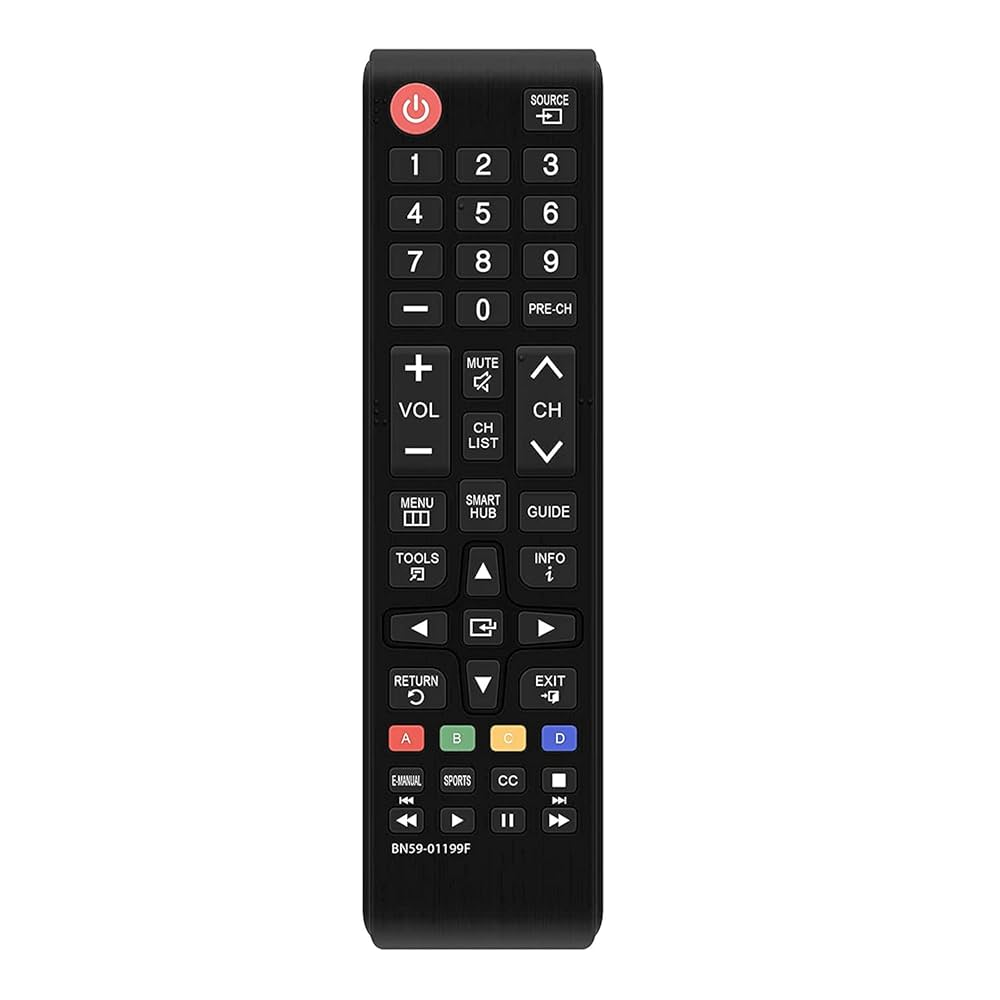

In [15]:
f"data:image/jpeg;base64,{base64_image}"

In [16]:
prompt = """
You are an image analysis assistant.

Identify all visible objects in the image.

Return the object names and approximate counts.

Return only JSON.

Example:

{
  "person": 2,
  "chair": 4,
  "table": 1
}
"""

response = client.chat.completions.create(
    model="gpt-4o",
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": prompt
                },
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/jpeg;base64,{base64_image}"
                    }
                }
            ]
        }
    ]
)

# Display Raw Model Output

This is exactly what the model returns.

In [17]:
raw_output = response.choices[0].message.content

print(raw_output)

```json
{
  "remote_control": 1
}
```



Image
 ↓
Base64 Encoding
 ↓
API Request
 ↓
GPT-4o Vision
 ↓
Image Understanding
 ↓
JSON Response
 ↓
Python Output